# Разведочный анализ цен и доходностей

Цель ноутбука — описать динамику скорректированных цен, распределения логарифмических доходностей, взаимосвязи активов и изменение волатильности. Полный период используется только для описания данных; решения о преобразованиях и будущей спецификации моделей принимаются по train. Экстремальные движения не удаляются.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from analysis.exploration import (  # noqa: E402
    add_rolling_volatility,
    return_correlation,
    summarize_returns,
)
from analysis.loading import load_raw_snapshot  # noqa: E402
from analysis.preparation import assign_time_split  # noqa: E402
from analysis.quality import add_log_returns  # noqa: E402

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Загрузка и подготовка

Снимок проверяется по манифесту. Доходности и скользящая волатильность рассчитываются функциями из модулей проекта. Для описательного сравнения дата наблюдения временно передаётся как `target_date`; это не меняет контракт модельного датасета.

In [2]:
snapshot = load_raw_snapshot(PROJECT_ROOT / "data" / "raw")
prices = snapshot.prices
returns = add_log_returns(prices)
explored = add_rolling_volatility(returns)
split_input = explored[["date"]].rename(columns={"date": "target_date"})
explored["split"] = assign_time_split(split_input)["split"].to_numpy()

summary = summarize_returns(explored)
pearson = return_correlation(explored, method="pearson")
spearman = return_correlation(explored, method="spearman")
display(summary)

,ticker,observations,mean_daily,median_daily,volatility_daily,mean_annualized,volatility_annualized,skewness,excess_kurtosis,minimum,q01,q05,median,q95,q99,maximum,maximum_drawdown
0,AAPL,5030,0.000954,0.000986,0.020016,0.240377,0.317752,-0.222215,6.559509,-0.197470,-0.056131,-0.030207,0.000986,0.031192,0.057197,0.142618,-0.608667
1,JPM,5030,0.000517,0.000530,0.022960,0.130407,0.364475,0.248191,17.437370,-0.232278,-0.064179,-0.030804,0.000530,0.029730,0.068386,0.223917,-0.681482
2,SPY,5030,0.000408,0.000701,0.012221,0.102889,0.193999,-0.304328,14.345850,-0.115886,-0.036363,-0.018171,0.000701,0.016492,0.031821,0.135577,-0.551894
3,XOM,5030,0.000279,0.000284,0.016747,0.070228,0.265843,-0.095907,9.870603,-0.150271,-0.047242,-0.024871,0.000284,0.024380,0.042998,0.158631,-0.623960


## Статистика по временным выборкам

Сравнение периодов помогает увидеть сдвиги распределения, но validation и test не используются для выбора преобразований или настройки моделей.

In [3]:
summary_by_split = pd.concat(
    [
        summarize_returns(group).assign(split=str(split))
        for split, group in explored.groupby("split", sort=False)
    ],
    ignore_index=True,
).loc[:, ["split", *summary.columns]]
summary_by_split

,split,ticker,observations,mean_daily,median_daily,volatility_daily,mean_annualized,volatility_annualized,skewness,excess_kurtosis,minimum,q01,q05,median,q95,q99,maximum,maximum_drawdown
0,train,AAPL,2516,0.000938,0.000897,0.021618,0.236332,0.343180,-0.296716,6.101237,-0.197470,-0.058573,-0.032476,0.000897,0.033979,0.058946,0.130194,-0.608667
1,train,JPM,2516,0.000297,0.000240,0.027442,0.074853,0.435629,0.322957,14.436948,-0.232278,-0.077481,-0.037518,0.000240,0.034700,0.089722,0.223917,-0.681482
2,train,SPY,2516,0.000271,0.000669,0.013016,0.068193,0.206622,-0.094255,13.441604,-0.103637,-0.042652,-0.019578,0.000669,0.017644,0.034520,0.135577,-0.551894
3,train,XOM,2516,0.000210,0.000167,0.015895,0.053033,0.252327,0.056807,14.510926,-0.150271,-0.045109,-0.022860,0.000167,0.022259,0.039462,0.158631,-0.372987
4,validation,AAPL,1006,0.001087,0.000976,0.015357,0.273976,0.243785,-0.463377,5.081454,-0.104924,-0.044954,-0.023715,0.000976,0.023177,0.041787,0.068052,-0.385159
5,validation,JPM,1006,0.000847,0.000539,0.013014,0.213487,0.206596,0.002388,3.794788,-0.072008,-0.038776,-0.019798,0.000539,0.021663,0.036198,0.079999,-0.217860
6,validation,SPY,1006,0.000532,0.000591,0.008125,0.133943,0.128984,-0.629941,4.718316,-0.042722,-0.025445,-0.013594,0.000591,0.012764,0.020402,0.049290,-0.193489
7,validation,XOM,1006,0.000048,0.000369,0.011386,0.012210,0.180752,-0.180459,2.622463,-0.058586,-0.030277,-0.019374,0.000369,0.017254,0.029290,0.050837,-0.242448
8,test,AAPL,1508,0.000892,0.001139,0.019995,0.224711,0.317408,0.027616,6.459841,-0.137708,-0.051051,-0.031193,0.001139,0.029942,0.051213,0.142618,-0.333605
9,test,JPM,1508,0.000665,0.000980,0.019730,0.167669,0.313196,-0.073767,12.531139,-0.162106,-0.052889,-0.028981,0.000980,0.025726,0.054041,0.165620,-0.436265


## Нормированная динамика цен

Каждый актив приведён к 100 на первой доступной дате, поэтому график сравнивает накопленную динамику, а не абсолютные уровни цен.

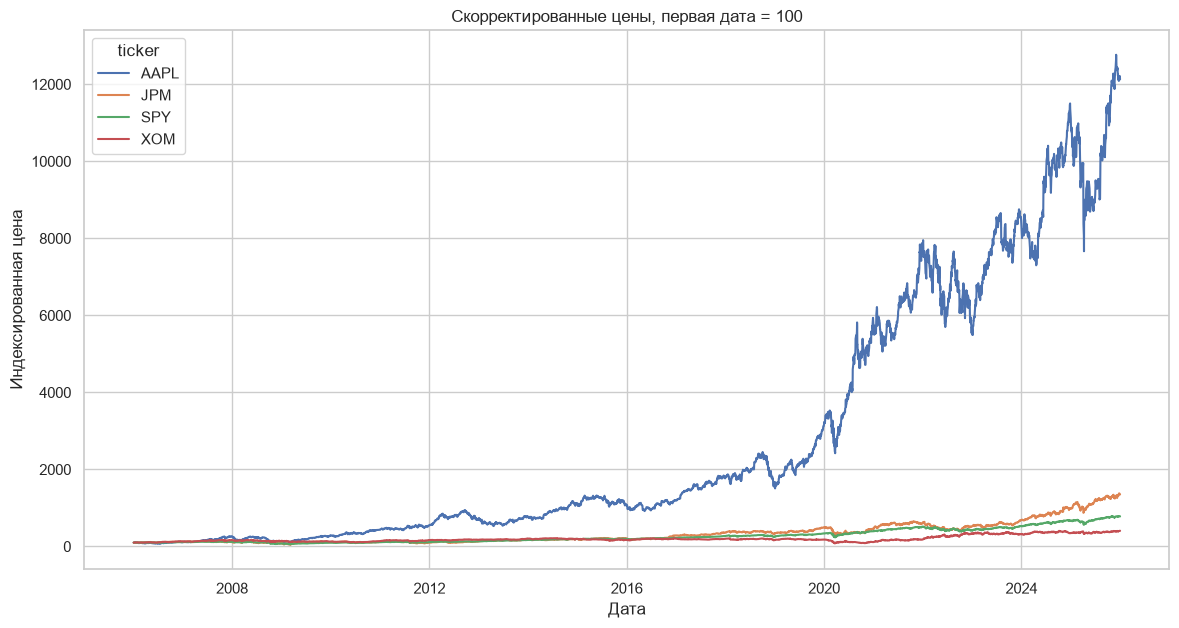

In [4]:
indexed_prices = prices.copy().sort_values(["ticker", "date"])
indexed_prices["indexed_adj_close"] = (
    indexed_prices["adj_close"]
    .div(indexed_prices.groupby("ticker")["adj_close"].transform("first"))
    .mul(100)
)
figure, axis = plt.subplots(figsize=(14, 7))
sns.lineplot(
    data=indexed_prices,
    x="date",
    y="indexed_adj_close",
    hue="ticker",
    ax=axis,
)
axis.set(
    title="Скорректированные цены, первая дата = 100",
    xlabel="Дата",
    ylabel="Индексированная цена",
)
plt.show()

## Доходности и скользящая волатильность

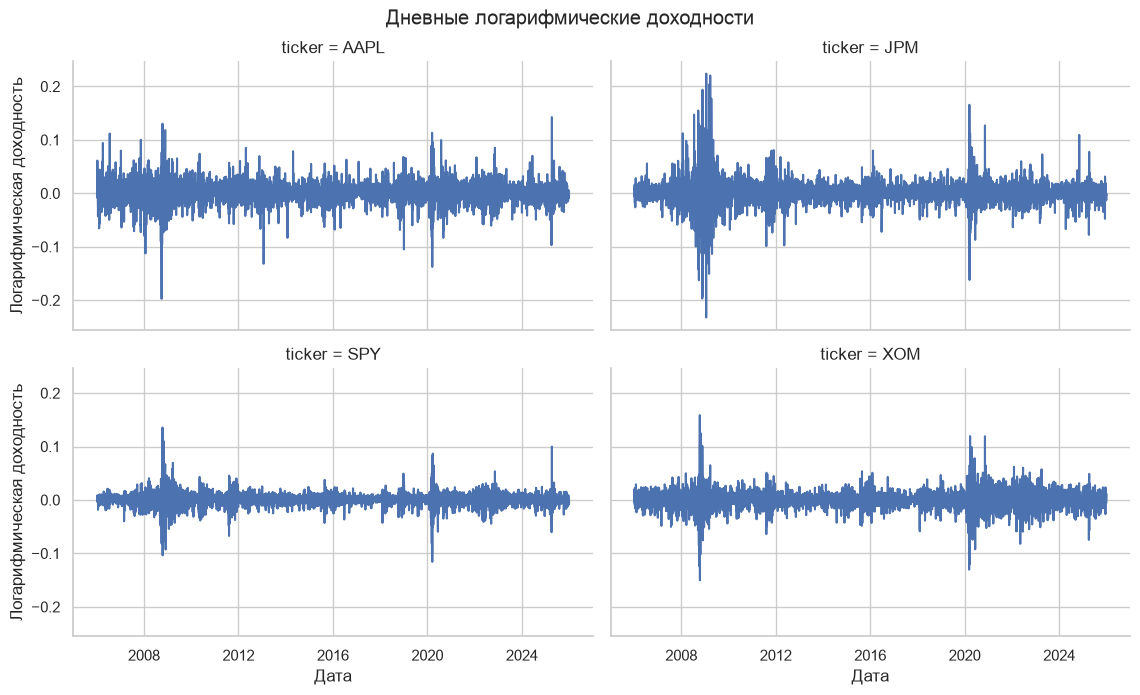

In [5]:
return_grid = sns.relplot(
    data=explored.dropna(subset=["log_return"]),
    x="date",
    y="log_return",
    col="ticker",
    col_wrap=2,
    kind="line",
    height=3.4,
    aspect=1.7,
    facet_kws={"sharey": True},
)
return_grid.set_axis_labels("Дата", "Логарифмическая доходность")
return_grid.figure.suptitle("Дневные логарифмические доходности", y=1.02)
plt.show()

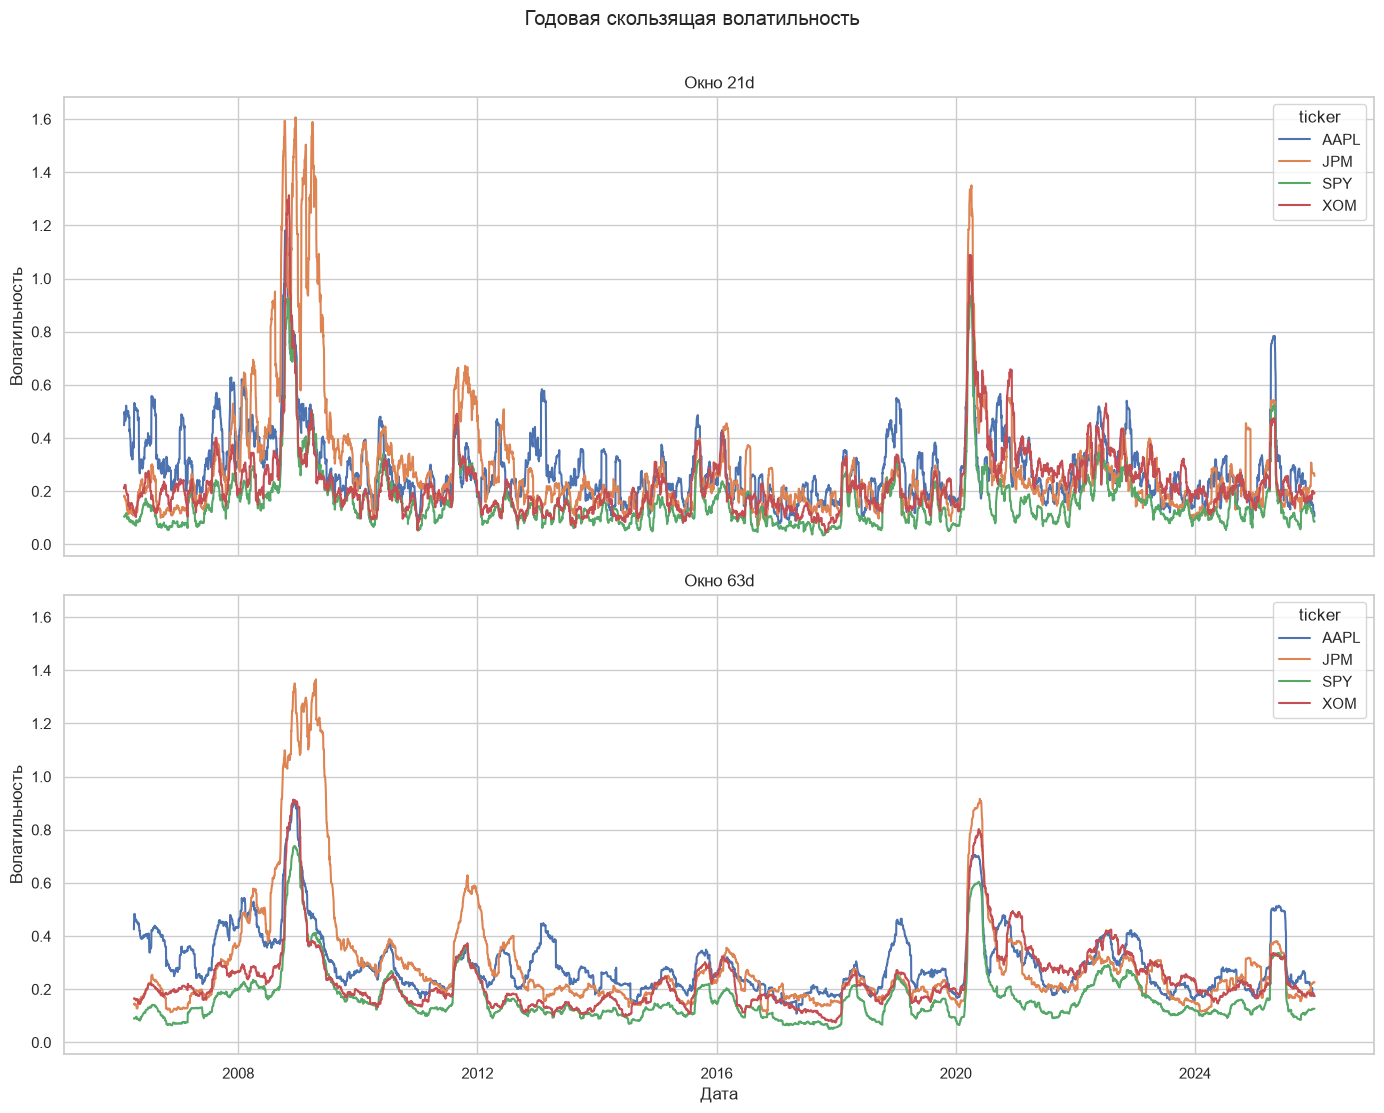

In [6]:
volatility_long = explored.melt(
    id_vars=["date", "ticker"],
    value_vars=["volatility_21d", "volatility_63d"],
    var_name="window",
    value_name="annualized_volatility",
)
figure, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True, sharey=True)
for axis, window in zip(axes, ["volatility_21d", "volatility_63d"], strict=True):
    sns.lineplot(
        data=volatility_long.loc[volatility_long["window"].eq(window)],
        x="date",
        y="annualized_volatility",
        hue="ticker",
        ax=axis,
    )
    axis.set(title=window.replace("volatility_", "Окно "), ylabel="Волатильность")
axes[-1].set_xlabel("Дата")
figure.suptitle("Годовая скользящая волатильность", y=1.01)
figure.tight_layout()
plt.show()

## Распределения и экстремальные движения

Гистограммы и boxplot построены по всем наблюдениям: экстремальные движения сохранены как часть рыночного процесса.

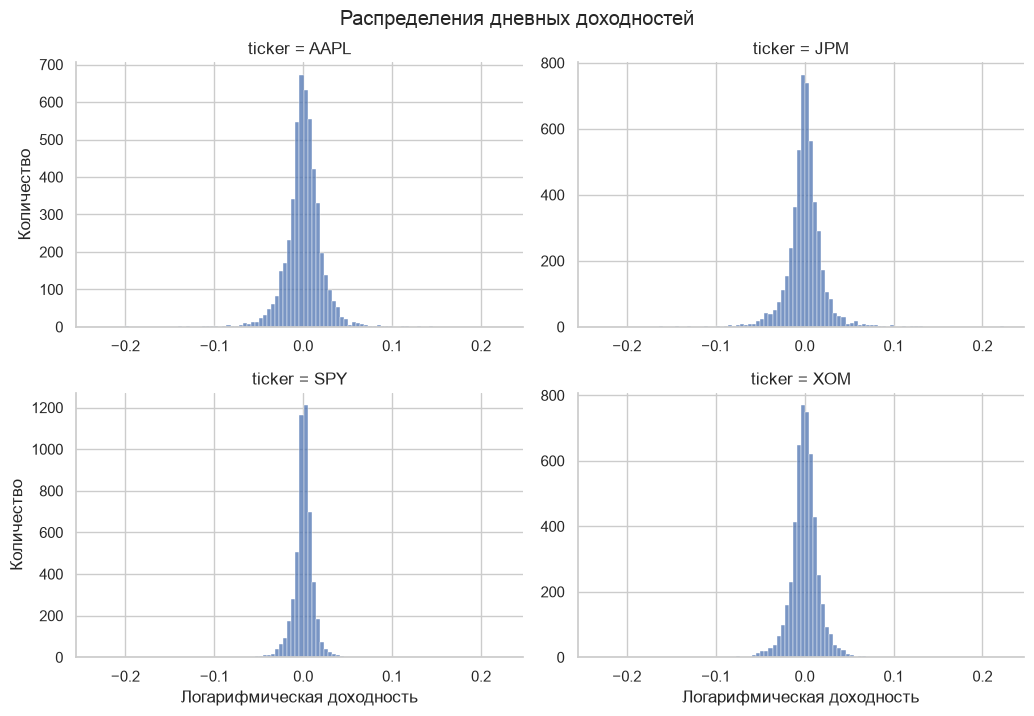

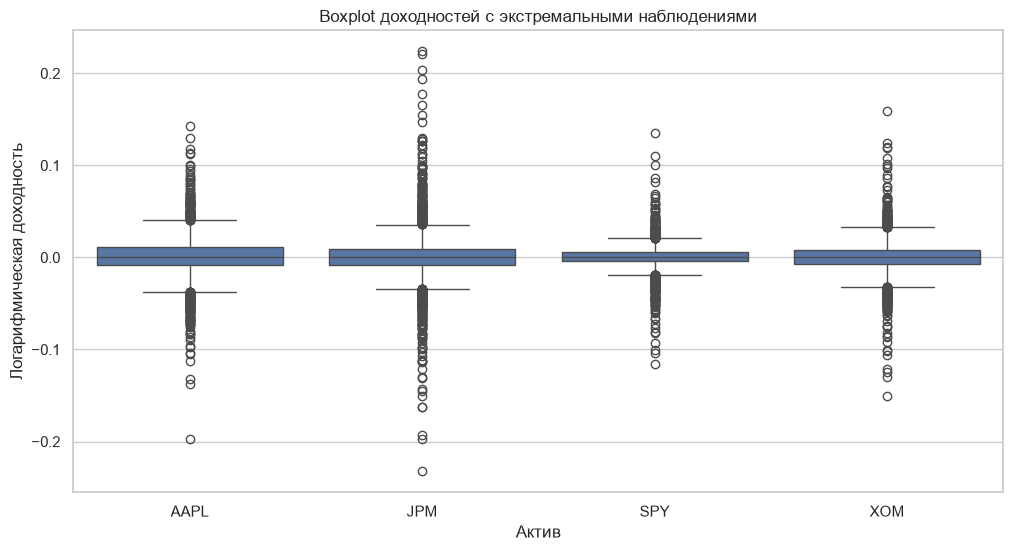

In [7]:
distribution = explored.dropna(subset=["log_return"])
histogram_grid = sns.displot(
    data=distribution,
    x="log_return",
    col="ticker",
    col_wrap=2,
    bins=100,
    height=3.5,
    aspect=1.5,
    facet_kws={"sharex": False, "sharey": False},
)
histogram_grid.set_axis_labels("Логарифмическая доходность", "Количество")
histogram_grid.figure.suptitle("Распределения дневных доходностей", y=1.02)
plt.show()

figure, axis = plt.subplots(figsize=(12, 6))
sns.boxplot(data=distribution, x="ticker", y="log_return", ax=axis, showfliers=True)
axis.set(
    title="Boxplot доходностей с экстремальными наблюдениями",
    xlabel="Актив",
    ylabel="Логарифмическая доходность",
)
plt.show()

## Корреляции доходностей

Pearson отражает линейную связь, Spearman — монотонную ранговую связь и менее чувствителен к величине экстремальных движений.

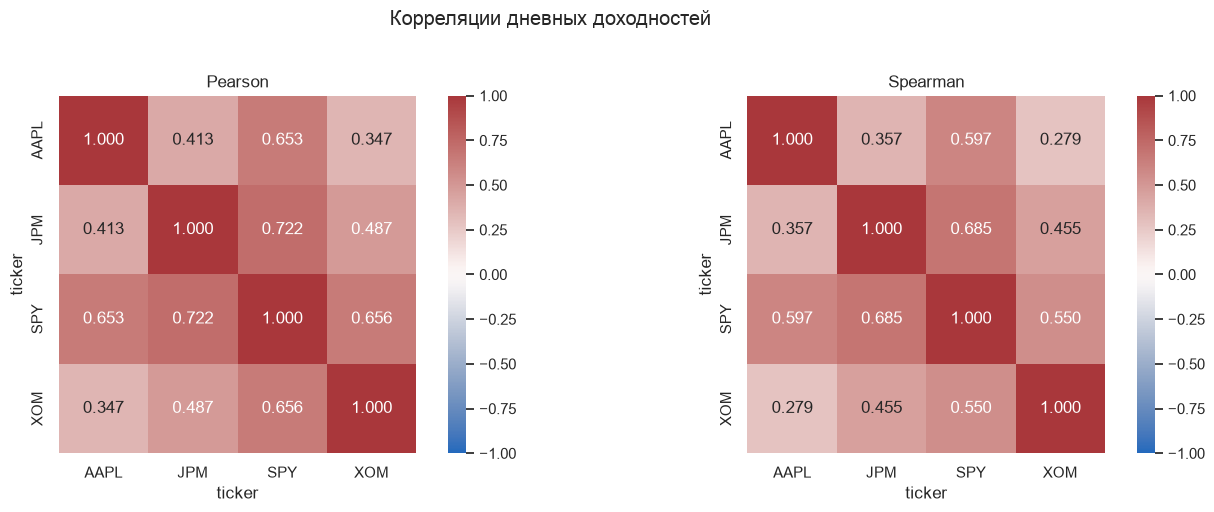

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, matrix, title in zip(
    axes,
    [pearson, spearman],
    ["Pearson", "Spearman"],
    strict=True,
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".3f",
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        ax=axis,
    )
    axis.set_title(title)
figure.suptitle("Корреляции дневных доходностей", y=1.02)
figure.tight_layout()
plt.show()

## Сравнение train, validation и test

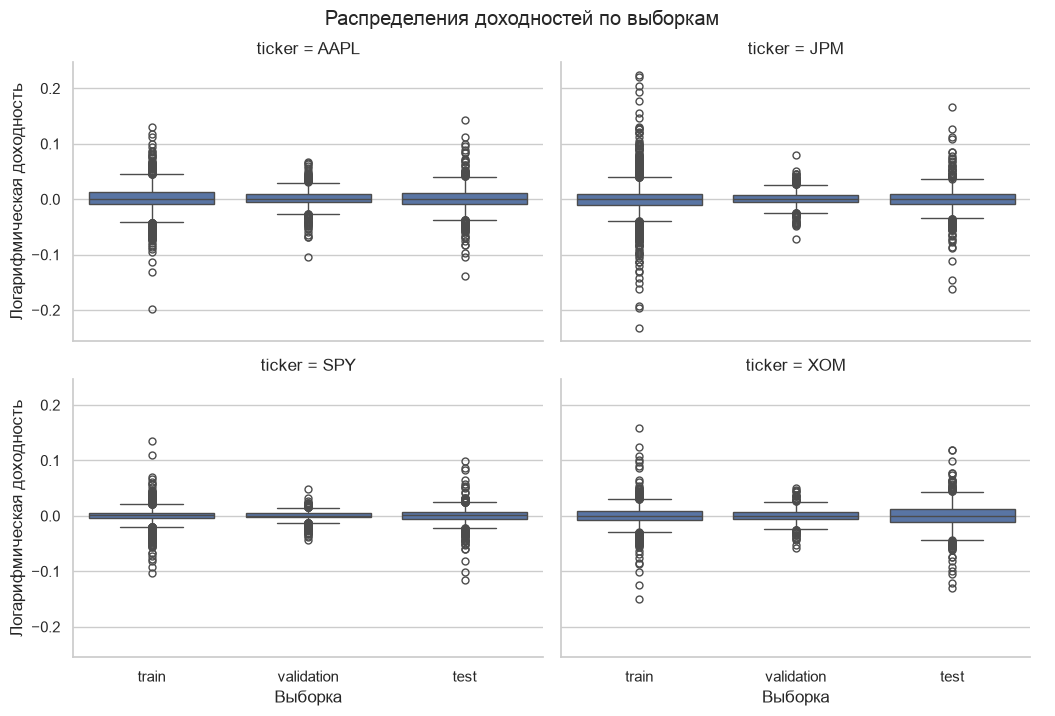

In [9]:
split_grid = sns.catplot(
    data=distribution,
    x="split",
    y="log_return",
    col="ticker",
    col_wrap=2,
    kind="box",
    order=["train", "validation", "test"],
    showfliers=True,
    height=3.5,
    aspect=1.5,
)
split_grid.set_axis_labels("Выборка", "Логарифмическая доходность")
split_grid.figure.suptitle("Распределения доходностей по выборкам", y=1.02)
plt.show()

In [10]:
largest_moves = (
    distribution.assign(abs_log_return=distribution["log_return"].abs())
    .nlargest(12, "abs_log_return")
    .loc[:, ["date", "ticker", "split", "log_return"]]
)
split_volatility = summary_by_split.pivot(
    index="ticker", columns="split", values="volatility_annualized"
).loc[:, ["train", "validation", "test"]]
display(split_volatility.style.format("{:.3f}"))
display(largest_moves)
display(pearson.style.format("{:.3f}"))
display(spearman.style.format("{:.3f}"))

split,train,validation,test
ticker,,,
AAPL,0.343,0.244,0.317
JPM,0.436,0.207,0.313
SPY,0.207,0.129,0.208
XOM,0.252,0.181,0.328


,date,ticker,split,log_return
5797,2009-01-20,JPM,train,-0.232278
5798,2009-01-21,JPM,train,0.223917
5840,2009-03-23,JPM,train,0.220462
5831,2009-03-10,JPM,train,0.204095
689,2008-09-29,AAPL,train,-0.197470
5758,2008-11-20,JPM,train,-0.196970
5760,2008-11-24,JPM,train,0.193845
5764,2008-12-01,JPM,train,-0.192353
5853,2009-04-09,JPM,train,0.177266
8603,2020-03-13,JPM,test,0.165620


ticker,AAPL,JPM,SPY,XOM
ticker,,,,
AAPL,1.000,0.413,0.653,0.347
JPM,0.413,1.000,0.722,0.487
SPY,0.653,0.722,1.000,0.656
XOM,0.347,0.487,0.656,1.000


ticker,AAPL,JPM,SPY,XOM
ticker,,,,
AAPL,1.000,0.357,0.597,0.279
JPM,0.357,1.000,0.685,0.455
SPY,0.597,0.685,1.000,0.550
XOM,0.279,0.455,0.550,1.000


## Выводы

- За 03.01.2006–31.12.2025 наибольший накопленный рост показала AAPL: скорректированная цена увеличилась примерно в 121.27 раза. Для JPM, SPY и XOM множители составили 13.50, 7.80 и 4.06 соответственно. Это описательное сравнение не используется как признак будущей модели.
- JPM имеет наибольшую волатильность полного периода — 36.4% в год — и максимальную просадку −68.1%. SPY наименее волатилен (19.4% в год), но его максимальная просадка всё равно достигает −55.2%.
- Волатильность зависит от временного режима. У всех активов validation спокойнее train. В test она снова выросла: особенно у XOM с 18.1% до 32.8%, JPM с 20.7% до 31.3% и AAPL с 24.4% до 31.7%. Следовательно, качество моделей необходимо проверять отдельно по режимам.
- Самая сильная связь наблюдается между JPM и SPY: Pearson = 0.722, Spearman = 0.685. Самая слабая — между AAPL и XOM: 0.347 и 0.279. Pearson выше Spearman для всех пар, поэтому крупные совместные движения усиливают линейную корреляцию.
- Распределения имеют тяжёлые хвосты: excess kurtosis равен 17.44 для JPM и 14.35 для SPY. Крупнейшие движения сосредоточены в кризисе 2008–2009 годов и в марте 2020 года. Эти наблюдения не удаляются, поскольку они отражают исследуемый рыночный риск.